In [54]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

options = {"thermal": "lumped"}

### For LFP/Graphite lihium ion cell

In [55]:
model = pybamm.lithium_ion.DFN()

In [56]:
# 2 Ah LFP|graphite cylindrical 18650 cell. The parameters are supplied by About:Energy BPX
parameter_values = pybamm.ParameterValues.create_from_bpx("lfp_18650_cell_BPX.json")

In [57]:
# Cell design specific parameters to be updated using values from the cell design tool

parameter_values.update({
                        "Negative electrode thickness [m]": 4.44e-05,
                        "Negative electrode porosity": 0.20666,
                        "Negative electrode active material volume fraction": 0.79334,
                        
                        
                        "Separator thickness [m]": 2e-5,
                        "Separator porosity": 0.47,
                        
                        "Positive electrode thickness [m]": 6.43e-5,
                        "Positive electrode porosity": 0.20359,
                        "Positive electrode active material volume fraction": 0.79641,
                        
                        #use the lesser values of (cathode, anode)
                        "Electrode height [m]": 65e-3, 
                        "Electrode width [m]": 1.37846,
                         
                        "Nominal cell capacity [A.h]": 2,
                        "Current function [A]": 2,
                        "Contact resistance [Ohm]": 0.0,
                        "Cell cooling surface area [m2]": 0.00431,
                        "Cell volume [m3]": 17e-06,
                        
                        },check_already_exists=False)

parameter_values.update({
                        
                        "Maximum concentration in negative electrode [mol.m-3]": 31400, #to be calculated from mAh/g
                        "Maximum concentration in positive electrode [mol.m-3]": 21200, #to be calculated from mAh/g
                        # leave it to default values for now
                        })

In [58]:
C_rates_in = 1

In [59]:
sim = pybamm.Simulation(model=model, parameter_values=parameter_values, C_rate=C_rates_in)
sim.solve([0, 4000/C_rates_in])
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.044622246188104, step=0.01044622246188104)…

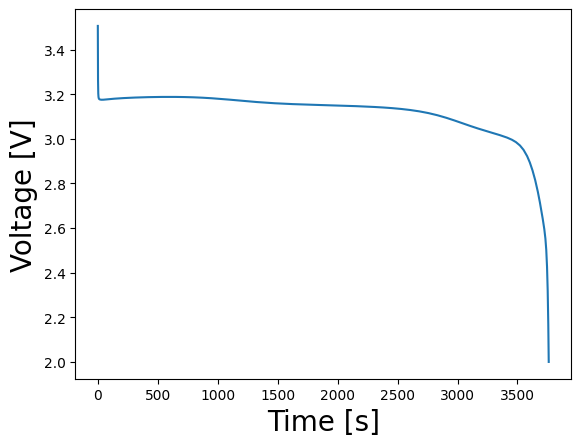

Text(0, 0.5, 'Voltage [V]')

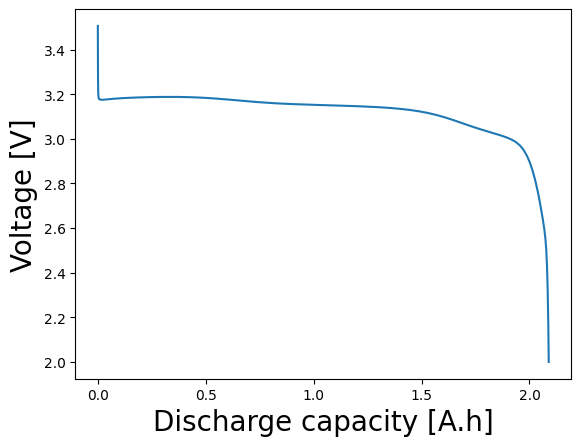

In [60]:
t1 = sim.solution["Time [s]"].entries
Vc1 = sim.solution["Battery voltage [V]"].entries
Qd1 = sim.solution["Discharge capacity [A.h]"].entries


plt.plot(t1, Vc1)
plt.xlabel("Time [s]",fontsize=20)
#plt.xlabel("Discharge capacity [A.h]", fontsize=20)
plt.ylabel("Voltage [V]", fontsize=20)
plt.show()
plt.plot(Qd1,Vc1)
#plt.xlabel("Time [h]",fontsize=20)
plt.xlabel("Discharge capacity [A.h]", fontsize=20)
plt.ylabel("Voltage [V]", fontsize=20)